# Phân tích các yếu tố ảnh hưởng và dự đoán mức độ nghiêm trọng của tai nạn giao thông

### Bộ dữ liệu: US Accidents (2016–2023)

### Nhóm câu hỏi phân tích dữ liệu
1. Tai nạn xảy ra nhiều nhất vào khung giờ nào?
2. Thời tiết nào liên quan đến nhiều vụ tai nạn nhất?
3. Những khu vực nào có số vụ tai nạn cao nhất?
4. Mức độ nghiêm trọng của tai nạn thay đổi theo thời gian ra sao?
5. Tai nạn có xu hướng tăng hay giảm theo từng năm?

### Nhóm câu hỏi về dự đoán, phân cụm hoặc phân lớp
1. Dự đoán mức độ nghiêm trọng của tai nạn.
2. Phân nhóm các khu vực theo mức độ rủi ro.

In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached jupyter_server_terminals-0.5.4-py3-none-any.whl.metadata (5.9 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached 


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Tiền xử lý dữ liệu

Dữ liệu gốc có kích thước rất lớn nên chỉ lấy mẫu ngẫu nhiên khoảng 3% dữ liệu từ mỗi khối dữ liệu để giảm tải bộ nhớ nhưng vẫn đảm bảo tính đại diện của toàn bộ tập dữ liệu.

In [89]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report

plt.style.use('dark_background')

# Lựa chọn các thuộc tính cần sử dụng
cols = [
    'Severity',
    'Start_Time',
    'City',
    'State',
    'Temperature(F)',
    'Humidity(%)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Weather_Condition',
    'Sunrise_Sunset'
]

chunks = []

# Đọc dữ liệu theo từng khối và lấy mẫu ngẫu nhiên 3%
for chunk in pd.read_csv(
    "US_Accidents_March23.csv",
    usecols=cols,
    chunksize=100000
):
    chunks.append(
        chunk.sample(
            frac=0.03,
            random_state=42
        )
    )

# Ghép dữ liệu
df = pd.concat(chunks)

# Loại bỏ giá trị thiếu
df = df.dropna()

# Chuyển đổi dữ liệu thời gian
df['Start_Time'] = pd.to_datetime(
    df['Start_Time'],
    format='mixed',
    errors='coerce'
)

df = df.dropna(subset=['Start_Time'])

# Trích xuất các thuộc tính thời gian
df['Hour'] = df['Start_Time'].dt.hour
df['Month'] = df['Start_Time'].dt.month
df['Year'] = df['Start_Time'].dt.year

# Kiểm tra dữ liệu sau tiền xử lý
print(f"Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")

print("\n5 bản ghi đầu tiên:")
print(df.head())

Kích thước dữ liệu: 211711 dòng, 13 cột

5 bản ghi đầu tiên:
       Severity          Start_Time        City State  Temperature(F)  \
80184         3 2016-09-28 12:33:15       Norco    CA            91.9   
19864         3 2016-09-13 20:16:23       Davis    CA            66.2   
92991         3 2016-08-27 17:56:49     Gardena    CA            72.0   
84004         3 2016-10-14 16:41:12  Long Beach    CA            70.0   
80917         3 2016-10-01 14:16:57     Anaheim    CA            84.0   

       Humidity(%)  Visibility(mi)  Wind_Speed(mph) Weather_Condition  \
80184         26.0            10.0              3.5             Clear   
19864         52.0            10.0              5.8             Clear   
92991         68.0            10.0              9.2             Clear   
84004         61.0            10.0             10.4             Clear   
80917         41.0            10.0              8.1             Clear   

      Sunrise_Sunset  Hour  Month  Year  
80184            Da

## Tổng quan dữ liệu

Thực hiện thống kê mô tả nhằm đánh giá đặc điểm của tập dữ liệu trước khi tiến hành phân tích chuyên sâu.

In [117]:
print(df.info())

print()

print(df.describe())

print()

print(df['Severity'].value_counts())

<class 'pandas.core.frame.DataFrame'>
Index: 211711 entries, 80184 to 7711203
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Severity              211711 non-null  int64         
 1   Start_Time            211711 non-null  datetime64[ns]
 2   City                  211711 non-null  object        
 3   State                 211711 non-null  object        
 4   Temperature(F)        211711 non-null  float64       
 5   Humidity(%)           211711 non-null  float64       
 6   Visibility(mi)        211711 non-null  float64       
 7   Wind_Speed(mph)       211711 non-null  float64       
 8   Weather_Condition     211711 non-null  object        
 9   Sunrise_Sunset        211711 non-null  object        
 10  Hour                  211711 non-null  int32         
 11  Month                 211711 non-null  int32         
 12  Year                  211711 non-null  int32         
 13 

## Chuẩn hóa dữ liệu thời tiết

Dữ liệu gốc được lưu bằng tiếng Anh. Để thuận tiện cho quá trình phân tích và trình bày kết quả, các điều kiện thời tiết được chuyển đổi sang tiếng Việt.

In [118]:
weather_dict = {
    'Fair':'Trời quang',
    'Cloudy':'Nhiều mây',
    'Mostly Cloudy':'Chủ yếu nhiều mây',
    'Partly Cloudy':'Có mây rải rác',

    'Clear':'Trời quang',
    'Mostly Clear':'Khá quang đãng',

    'Light Rain':'Mưa nhẹ',
    'Rain':'Mưa',
    'Heavy Rain':'Mưa lớn',

    'Light Snow':'Tuyết nhẹ',
    'Snow':'Tuyết',
    'Heavy Snow':'Tuyết lớn',

    'Fog':'Sương mù',
    'Mist':'Sương nhẹ',
    'Haze':'Mù khô',

    'Thunderstorm':'Dông bão',
    'Light Thunderstorms and Rain':'Dông và mưa nhẹ',

    'Drizzle':'Mưa phùn',
    'Smoke':'Khói',
    'Overcast':'U ám'
}

df['Weather_Condition_VN'] = (
    df['Weather_Condition']
    .replace(weather_dict)
)

# Câu hỏi 1. Tai nạn xảy ra nhiều nhất vào khung giờ nào?

In [119]:
hour_data = (
    df['Hour']
    .value_counts()
    .sort_index()
    .reset_index()
)

hour_data.columns = [
    'Giờ',
    'Số vụ tai nạn'
]

hour_data

,Giờ,Số vụ tai nạn
0,0,3046
1,1,2633
2,2,2589
3,3,2219
4,4,4143
5,5,5980
6,6,10678
7,7,15264
8,8,15299
9,9,9651


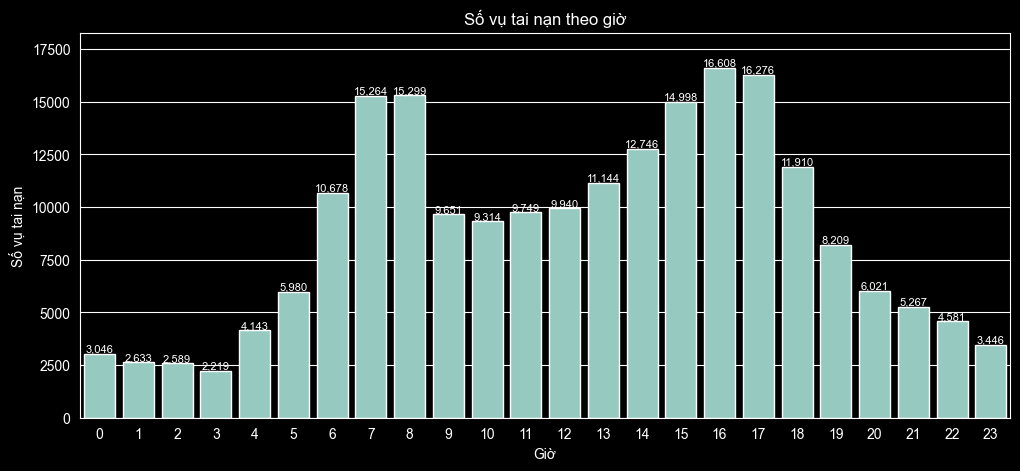

In [120]:
plt.figure(figsize=(12,5))

# Vẽ biểu đồ cột thể hiện số vụ tai nạn theo giờ
ax = sns.barplot(
    x=hour_data['Giờ'],
    y=hour_data['Số vụ tai nạn']
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (
            p.get_x() + p.get_width()/2,
            p.get_height()
        ),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title("Số vụ tai nạn theo giờ")
plt.xlabel("Giờ")
plt.ylabel("Số vụ tai nạn")

plt.ylim(
    0,
    hour_data['Số vụ tai nạn'].max() * 1.1
)

plt.savefig(
    "cau_1.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Câu hỏi 2. Điều kiện thời tiết nào liên quan đến nhiều vụ tai nạn nhất?

In [121]:
# Thống kê số vụ tai nạn theo điều kiện thời tiết
weather_data = (
    df['Weather_Condition_VN']
    .value_counts() # Đếm số vụ tai nạn theo từng điều kiện thời tiết
    .head(10)
    .reset_index()
)

weather_data.columns = [
    'Điều kiện thời tiết',
    'Số vụ tai nạn'
]

weather_data

,Điều kiện thời tiết,Số vụ tai nạn
0,Trời quang,93785
1,Chủ yếu nhiều mây,28926
2,Nhiều mây,24280
3,Có mây rải rác,19831
4,Mưa nhẹ,10032
5,U ám,9710
6,Scattered Clouds,5256
7,Tuyết nhẹ,3689
8,Sương mù,2731
9,Mưa,2300


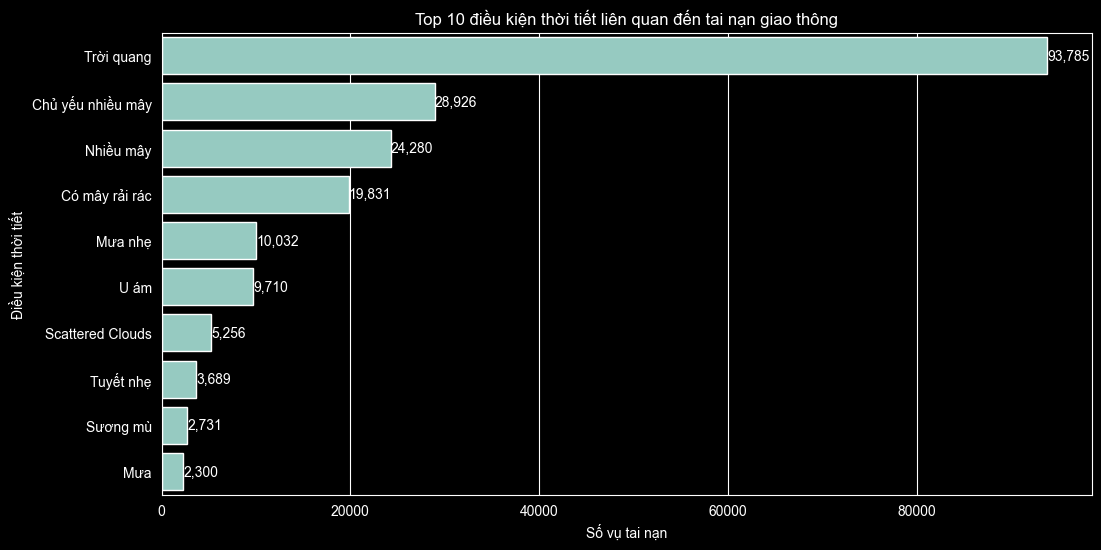

In [122]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=weather_data,
    x='Số vụ tai nạn',
    y='Điều kiện thời tiết'
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_width()):,}",
        (
            p.get_width(),
            p.get_y() + p.get_height()/2
        ),
        ha='left',
        va='center'
    )

plt.title(
    'Top 10 điều kiện thời tiết liên quan đến tai nạn giao thông'
)

plt.xlabel('Số vụ tai nạn')
plt.ylabel('Điều kiện thời tiết')

plt.savefig(
    'cau_2.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Câu hỏi 3. Những khu vực nào có số vụ tai nạn giao thông cao nhất?

In [123]:
# Thống kê số vụ tai nạn theo khu vực
state_data = (
    df['State']
    .value_counts()
    .head(10)
    .reset_index()
)

state_data.columns = [
    'Khu vực',
    'Số vụ tai nạn'
]

state_data

,Khu vực,Số vụ tai nạn
0,CA,47328
1,FL,24606
2,TX,16127
3,SC,10573
4,NY,9794
5,NC,9376
6,VA,8097
7,PA,7955
8,MN,5334
9,TN,4866


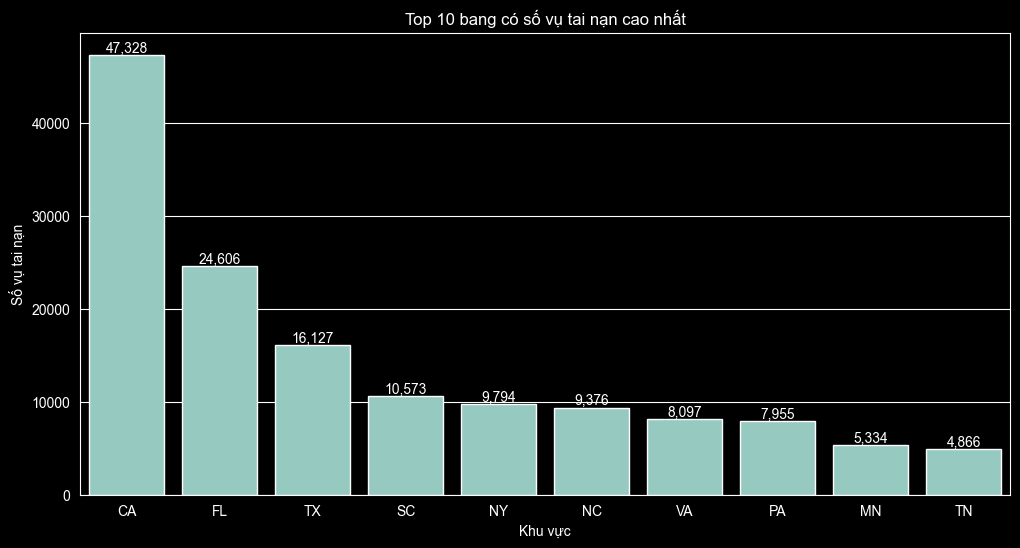

In [124]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=state_data,
    x='Khu vực',
    y='Số vụ tai nạn'
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (
            p.get_x() + p.get_width()/2,
            p.get_height()
        ),
        ha='center',
        va='bottom'
    )

plt.title(
    'Top 10 bang có số vụ tai nạn cao nhất'
)

plt.xlabel('Khu vực')
plt.ylabel('Số vụ tai nạn')

plt.savefig(
    'cau_3.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Câu hỏi 4. Mức độ nghiêm trọng của tai nạn thay đổi theo thời gian như thế nào?

In [125]:
severity_year = (
    df.groupby('Year')
    ['Severity']
    .mean() # Tính mức độ nghiêm trọng trung bình theo năm
    .reset_index()
)

severity_year.columns = [
    'Năm',
    'Severity trung bình'
]

severity_year

,Năm,Severity trung bình
0,2016,2.385713
1,2017,2.383588
2,2018,2.384246
3,2019,2.306443
4,2020,2.183425
5,2021,2.130636
6,2022,2.072116
7,2023,2.053739


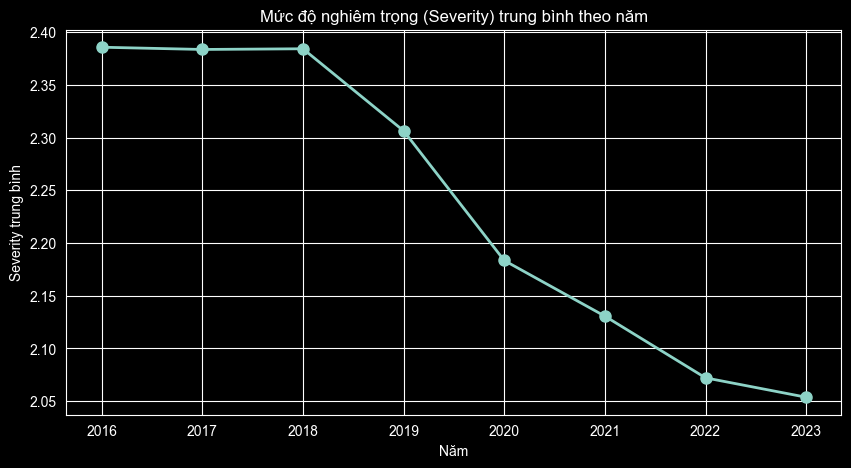

In [126]:
plt.figure(figsize=(10,5))

plt.plot(
    severity_year['Năm'],
    severity_year['Severity trung bình'],
    marker='o',
    linewidth=2,
    markersize=8
)

plt.title(
    'Mức độ nghiêm trọng (Severity) trung bình theo năm'
)

plt.xlabel('Năm')
plt.ylabel('Severity trung bình')

plt.grid(True)

plt.savefig(
    'cau_4.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Câu hỏi 5. Tai nạn giao thông có xu hướng tăng hay giảm theo từng năm?

In [127]:
accident_year = (
    df['Year']
    .value_counts() # Thống kê số vụ tai nạn theo từng năm
    .sort_index()
    .reset_index()
)

accident_year.columns = [
    'Năm',
    'Số vụ tai nạn'
]

accident_year

,Năm,Số vụ tai nạn
0,2016,9743
1,2017,17438
2,2018,21429
3,2019,26589
4,2020,33954
5,2021,45133
6,2022,50391
7,2023,7034


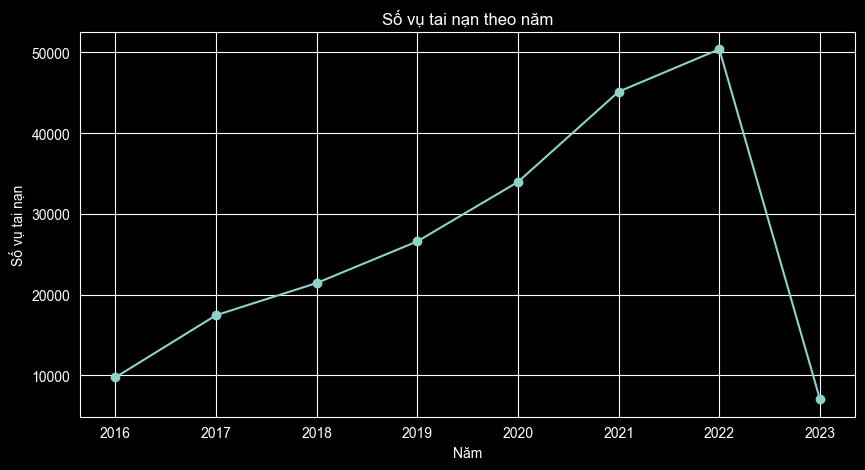

In [128]:
plt.figure(figsize=(10,5))

plt.plot(
    accident_year['Năm'],
    accident_year['Số vụ tai nạn'],
    marker='o'
)

plt.title(
    'Số vụ tai nạn theo năm'
)

plt.xlabel('Năm')
plt.ylabel('Số vụ tai nạn')

plt.grid(True)

plt.savefig(
    'cau_5.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Câu hỏi 6. Có thể dự đoán mức độ nghiêm trọng của tai nạn giao thông hay không?

### Bước 1: Chuẩn bị dữ liệu

Một số thuộc tính trong bộ dữ liệu ở dạng văn bản như điều kiện thời tiết hoặc thời điểm ngày/đêm.

Do các thuật toán học máy chỉ xử lý được dữ liệu số nên cần chuyển đổi các giá trị này thành dạng số.

In [138]:
from sklearn.preprocessing import LabelEncoder

le_weather = LabelEncoder()
le_daynight = LabelEncoder()

# Chuyển điều kiện thời tiết từ dạng chữ sang số
df['Weather_Condition'] = le_weather.fit_transform(
    df['Weather_Condition']
)

# Chuyển dữ liệu ngày/đêm từ dạng chữ sang số
df['Sunrise_Sunset'] = le_daynight.fit_transform(
    df['Sunrise_Sunset']
)

### Bước 2: Lựa chọn biến đầu vào

Các yếu tố được sử dụng để dự đoán mức độ nghiêm trọng của tai nạn bao gồm:

- Nhiệt độ
- Độ ẩm
- Tầm nhìn
- Tốc độ gió
- Điều kiện thời tiết
- Ban ngày hoặc ban đêm
- Giờ xảy ra tai nạn
- Tháng xảy ra tai nạn

In [139]:
features = [
    'Temperature(F)',
    'Humidity(%)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Weather_Condition',
    'Sunrise_Sunset',
    'Hour',
    'Month'
]

# Xác định các biến đầu vào của mô hình
X = df[features]

# Xác định biến mục tiêu cần dự đoán
y = df['Severity']

### Bước 3: Chia dữ liệu huấn luyện và kiểm tra

Tập dữ liệu được chia thành:

- 80% dùng để huấn luyện mô hình
- 20% dùng để kiểm tra mô hình

In [140]:
from sklearn.model_selection import train_test_split

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

### Bước 4: Huấn luyện mô hình Random Forest

Random Forest là thuật toán học máy phổ biến có khả năng xử lý dữ liệu lớn và đánh giá tầm quan trọng của các thuộc tính.

In [51]:
from sklearn.ensemble import RandomForestClassifier

# Khởi tạo mô hình Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Huấn luyện mô hình
rf.fit(
    X_train,
    y_train
)

# Dự đoán kết quả trên tập kiểm tra
y_pred = rf.predict(
    X_test
)

### Bước 5: Đánh giá kết q

In [141]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

# Tính độ chính xác của mô hình
print(
    "Độ chính xác:",
    accuracy_score(
        y_test,
        y_pred
    )
)

# Đánh giá chi tiết Precision, Recall, F1-score
print(
    classification_report(
        y_test,
        y_pred
    )
)

Độ chính xác: 0.7954089223720567
              precision    recall  f1-score   support

           1       0.14      0.01      0.01       403
           2       0.81      0.98      0.89     34092
           3       0.33      0.06      0.10      6821
           4       0.21      0.02      0.03      1027

    accuracy                           0.80     42343
   macro avg       0.38      0.26      0.26     42343
weighted avg       0.71      0.80      0.73     42343



### BƯỚC 6: XÁC ĐỊNH YẾU TỐ ẢNH HƯỞNG
Đây là phần rất quan trọng vì đề tài của bạn là: Phân tích các yếu tố ảnh hưởng

In [142]:
importance = pd.DataFrame({
    'Yếu tố': [
        'Nhiệt độ',
        'Độ ẩm',
        'Tầm nhìn',
        'Tốc độ gió',
        'Điều kiện thời tiết',
        'Ngày/Đêm',
        'Giờ',
        'Tháng'
    ],
    'Mức độ ảnh hưởng':
    rf.feature_importances_
})

importance = importance.sort_values(
    by='Mức độ ảnh hưởng',
    ascending=False
)

importance

,Yếu tố,Mức độ ảnh hưởng
0,Nhiệt độ,0.248536
1,Độ ẩm,0.243320
3,Tốc độ gió,0.152849
6,Giờ,0.144789
7,Tháng,0.087425
4,Điều kiện thời tiết,0.069390
2,Tầm nhìn,0.045616
5,Ngày/Đêm,0.008075


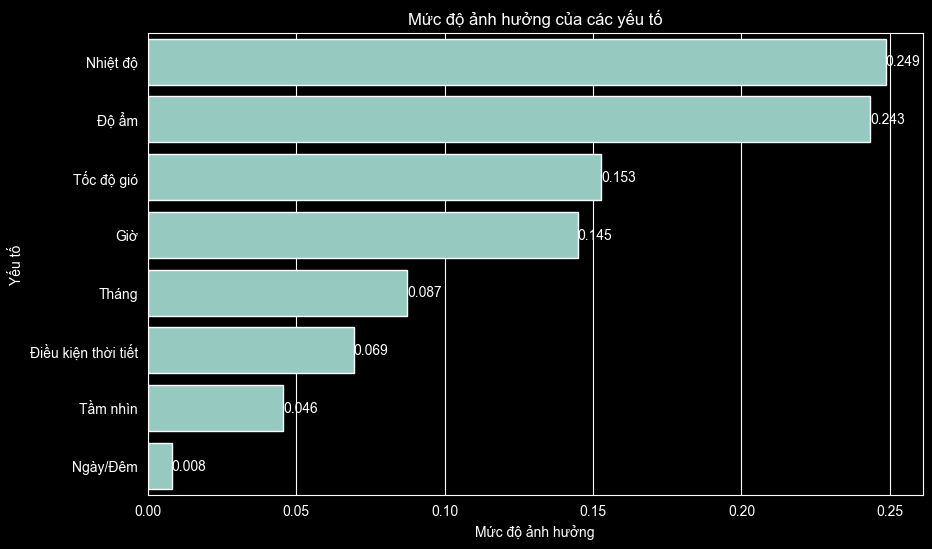

In [143]:
plt.figure(figsize=(10,6))

# Trực quan hóa mức độ ảnh hưởng của các yếu tố
ax = sns.barplot(
    data=importance,
    x='Mức độ ảnh hưởng',
    y='Yếu tố'
)

plt.title(
    'Mức độ ảnh hưởng của các yếu tố'
)

plt.xlabel(
    'Mức độ ảnh hưởng'
)

plt.ylabel(
    'Yếu tố'
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.3f}",
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left',
        va='center'
    )

plt.savefig(
    'cau_6.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Kết luận

Tầm nhìn, điều kiện thời tiết và thời gian xảy ra tai nạn là những yếu tố có ảnh hưởng lớn đến mức độ nghiêm trọng của tai nạn giao thông.

Kết quả này phù hợp với thực tế khi điều kiện môi trường xấu thường làm gia tăng nguy cơ tai nạn nghiêm trọng.

# Câu hỏi 7. Các khu vực có thể được phân thành những nhóm rủi ro tai nạn nào?

### Bước 1: Chuẩn bị dữ liệu

Mỗi khu vực được mô tả bởi hai đặc trưng:

- Số lượng vụ tai nạn giao thông.
- Mức độ nghiêm trọng trung bình của các vụ tai nạn.

Các đặc trưng này sẽ được sử dụng làm đầu vào cho thuật toán K-Means.

In [144]:
cluster_df = (
    df.groupby('State') # Gom dữ liệu theo khu vực
    .agg({
        'Severity':'mean'
    })
    .reset_index()
)

counts = (
    df['State']
    .value_counts() # Đếm số vụ tai nạn theo khu vực
)

cluster_df['So_Vu_Tai_Nan'] = (
    cluster_df['State']
    .map(counts)
)

cluster_df.columns = [
    'Khu vực',
    'Mức độ nghiêm trọng trung bình',
    'Số vụ tai nạn'
]

cluster_df.head()

,Khu vực,Mức độ nghiêm trọng trung bình,Số vụ tai nạn
0,AL,2.248945,2844
1,AR,2.263339,581
2,AZ,2.107941,4521
3,CA,2.146319,47328
4,CO,2.451146,2487


### Bước 2: Phân cụm dữ liệu bằng K-Means

Thuật toán K-Means được sử dụng để chia các khu vực thành 3 nhóm dựa trên:

- Mức độ nghiêm trọng trung bình.
- Số vụ tai nạn.

Ba nhóm tương ứng với các mức độ rủi ro khác nhau.

In [145]:
from sklearn.cluster import KMeans

X_cluster = cluster_df[
    [
        'Mức độ nghiêm trọng trung bình',
        'Số vụ tai nạn'
    ]
]

# Khởi tạo mô hình K-Means với 3 nhóm rủi ro.
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# Thực hiện phân cụm các khu vực bằng thuật toán K-Means.
cluster_df['Nhóm'] = (
    kmeans.fit_predict(
        X_cluster
    )
)

cluster_df.head()

,Khu vực,Mức độ nghiêm trọng trung bình,Số vụ tai nạn,Nhóm
0,AL,2.248945,2844,0
1,AR,2.263339,581,0
2,AZ,2.107941,4521,0
3,CA,2.146319,47328,2
4,CO,2.451146,2487,0


### Bước 3: Xác định mức độ rủi ro

Sau khi phân cụm, các nhóm sẽ được sắp xếp theo số lượng tai nạn trung bình và gán tên:

- Rủi ro thấp
- Rủi ro trung bình
- Rủi ro cao

Việc đặt tên giúp kết quả trực quan và dễ hiểu hơn.

In [166]:
group_info = (
    cluster_df.groupby('Nhóm')
    [
        ['Số vụ tai nạn']
    ]
    .mean() # Tính số vụ tai nạn trung bình của từng nhóm
    .sort_values(
        by='Số vụ tai nạn'
    )
)

risk_names = [
    'Rủi ro thấp',
    'Rủi ro trung bình',
    'Rủi ro cao'
]

mapping = {
    group_info.index[i]: risk_names[i]
    for i in range(3)
}

cluster_df['Nhóm rủi ro'] = (
    cluster_df['Nhóm']
    .map(mapping)
)

cluster_df[
    [
        'Khu vực',
        'Mức độ nghiêm trọng trung bình',
        'Số vụ tai nạn',
        'Nhóm rủi ro'
    ]
].head(20)

,Khu vực,Mức độ nghiêm trọng trung bình,Số vụ tai nạn,Nhóm rủi ro
0,AL,2.248945,2844,Rủi ro thấp
1,AR,2.263339,581,Rủi ro thấp
2,AZ,2.107941,4521,Rủi ro thấp
3,CA,2.146319,47328,Rủi ro cao
4,CO,2.451146,2487,Rủi ro thấp
5,CT,2.342522,1959,Rủi ro thấp
6,DC,2.131528,517,Rủi ro thấp
7,DE,2.211196,393,Rủi ro thấp
8,FL,2.132976,24606,Rủi ro trung bình
9,GA,2.492401,4606,Rủi ro thấp


### Bước 4: Phân tích kết quả phân cụm

Thực hiện thống kê số lượng khu vực trong từng nhóm rủi ro và trực quan hóa kết quả bằng biểu đồ phân tán (Scatter Plot).

Nhóm rủi ro
Rủi ro thấp          46
Rủi ro trung bình     2
Rủi ro cao            1
Name: count, dtype: int64


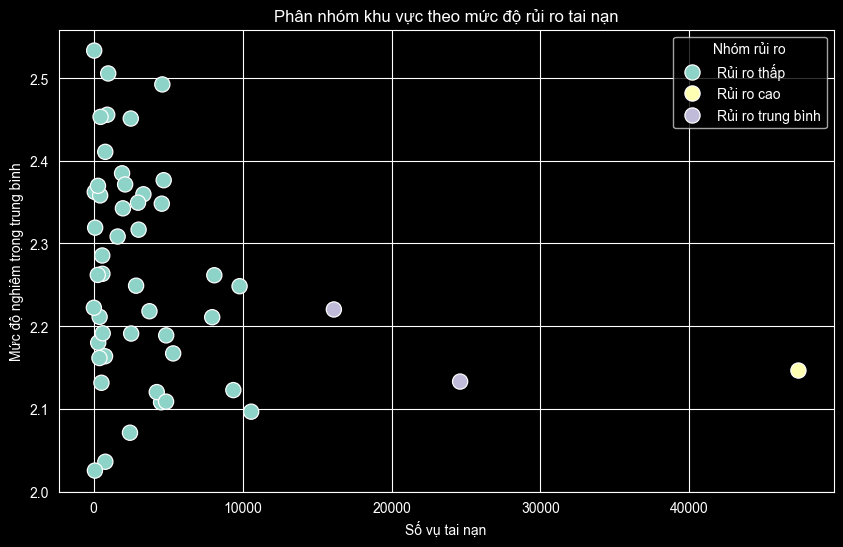

In [167]:
# Thống kê số khu vực trong từng nhóm rủi ro
print(
    cluster_df['Nhóm rủi ro']
    .value_counts()
)

plt.figure(figsize=(10,6))

# Hiển thị các nhóm rủi ro trên biểu đồ phân tán để quan sát sự khác biệt giữa các khu vực.
sns.scatterplot(
    data=cluster_df,
    x='Số vụ tai nạn',
    y='Mức độ nghiêm trọng trung bình',
    hue='Nhóm rủi ro',
    s=120
)

plt.title(
    'Phân nhóm khu vực theo mức độ rủi ro tai nạn'
)

plt.xlabel(
    'Số vụ tai nạn'
)

plt.ylabel(
    'Mức độ nghiêm trọng trung bình'
)

plt.savefig(
    'cau_7.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Kết luận

Thuật toán K-Means đã phân chia các khu vực thành ba nhóm có đặc điểm tai nạn tương đồng.

Kết quả cho thấy sự khác biệt rõ rệt giữa các khu vực về số lượng tai nạn và mức độ nghiêm trọng trung bình. Những khu vực thuộc nhóm có số vụ tai nạn cao và mức độ nghiêm trọng lớn cần được ưu tiên trong công tác giám sát, quy hoạch giao thông và triển khai các giải pháp đảm bảo an toàn giao thông.

Việc áp dụng kỹ thuật phân cụm giúp hỗ trợ quá trình ra quyết định và đánh giá rủi ro giao thông một cách hiệu quả hơn.